# Individual Homework 2 — Explaining the COMPAS Replacement Model

This notebook builds on `Lecture_01_alignment_python_MCHALE.ipynb`.
All variable names, factor columns, and the target are carried over exactly as
defined in HW1.

We apply three post-hoc explainability methods to the HW1 logistic regression:

1. **SHAP** — global beeswarm summary + per-individual waterfall plots
2. **LIME** — local linear explanations for four focal individuals
3. **DiCE** — counterfactual explanations; immutable features (race, sex) flagged

### HW1 used: pandas, numpy, matplotlib, seaborn, statsmodels, scipy.
### HW2 adds three explainability libraries and scikit-learn:
    shap        — SHapley Additive exPlanations (global + local attribution)
    lime        — Local Interpretable Model-agnostic Explanations
    dice-ml     — Diverse Counterfactual Explanations
    scikit-learn — Required by all three libraries. statsmodels' fitted
                   logit object does NOT expose .predict_proba(), which SHAP,
                   LIME, and DiCE all need. We refit the identical model in
                   sklearn so the coefficients stay as close as possible to
                   the HW1 statsmodels output
### Run once; restart the Colab runtime after installation before continuing.

In [1]:
# ── Cell 1: Install Additional Dependencies ───────────────────────────────────
!pip install shap lime dice-ml scikit-learn --quiet

In [2]:
# ── Cell 2: Imports ───────────────────────────────────────────────────────────
import warnings
warnings.filterwarnings('ignore')

import math
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns
import statsmodels.formula.api as smf
from scipy import stats

# sklearn — needed for SHAP / LIME / DiCE compatibility
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder
from sklearn.pipeline import Pipeline as SKPipeline

# Explainability libraries
import shap
import lime
import lime.lime_tabular
import dice_ml
from dice_ml import Dice

---
## Reproduce the HW1 Data Pipeline

We rebuild df and all factor columns from scratch so this notebook is
self-contained. Every variable name, filter, and encoding choice is identical
to Lecture_01_alignment_python_MCHALE.ipynb.

### Variable reference

| HW1 variable | Column in df | Definition |

| `gender_factor` | derived from `sex` | Defendant sex; ref = Male |

| `age_factor` | derived from `age_cat` | Age bracket; ref = 25–45 |

| `race_factor` | derived from `race` | Self-reported race; ref = Caucasian |

| `priors_count` | raw numeric | Number of prior convictions |

| `crime_factor` | derived from `c_charge_degree` | Charge severity (F/M) |

| `two_year_recid` | raw binary (0/1) | Did defendant reoffend within 2 yrs? |

| `score_factor` | derived from `score_text` | LowScore / HighScore label |

| **`score_factor_num`** | **TARGET** | **0 = LowScore, 1 = HighScore** |

In [3]:
# ── Cell 3: Load and Filter Data ─────────────────────────────────────────────
# Four filters:
#   ±30-day window  — ensures COMPAS score matched to correct offense
#   is_recid != -1  — drops rows with no matching COMPAS case
#   charge != 'O'   — removes traffic-only offenses (no jail risk)
#   score != 'N/A'  — removes rows with no COMPAS risk label

url = "https://raw.githubusercontent.com/propublica/compas-analysis/master/compas-scores-two-years.csv"
raw_data = pd.read_csv(url)

datetime_vars = ["c_jail_in", "c_jail_out"]
numeric_vars  = ["age", "priors_count", "days_b_screening_arrest", "decile_score"]

df = (
    raw_data[
        ["age", "c_charge_degree", "race", "age_cat", "score_text", "sex",
         "priors_count", "days_b_screening_arrest", "decile_score",
         "is_recid", "two_year_recid", "c_jail_in", "c_jail_out"]
    ]
    .query("-30 <= days_b_screening_arrest <= 30")
    .query("is_recid != -1")
    .query("c_charge_degree != 'O'")
    .query("score_text != 'N/A'")
    .copy()
)

for col in datetime_vars:
    df[col] = pd.to_datetime(df[col], format="%Y-%m-%d %H:%M:%S", utc=True)

cat_cols = [c for c in df.columns if c not in numeric_vars + datetime_vars]
for col in cat_cols:
    df[col] = df[col].astype("category")

# ── Exact factor columns from HW1 Cell 5 ────────────────────────────────────

# crime_factor: charge severity — F (Felony) or M (Misdemeanor)
# Source column: c_charge_degree
df["crime_factor"] = df["c_charge_degree"].astype("category")

# age_factor: defendant age bracket
# Source column: age_cat  |  Values: Less than 25 | 25 - 45 | Greater than 45
# Reference level: "25 - 45" (largest group; R: relevel(age_factor, ref=1))
df["age_factor"] = pd.Categorical(
    df["age_cat"],
    categories=["25 - 45"] + [c for c in df["age_cat"].cat.categories if c != "25 - 45"],
    ordered=False
)

# race_factor: defendant self-reported race
# Source column: race
# Values: African-American | Asian | Caucasian | Hispanic | Native American | Other
# Reference level: "Caucasian" (R: relevel(race_factor, ref=3))
df["race_factor"] = pd.Categorical(
    df["race"],
    categories=["Caucasian"] + [c for c in df["race"].cat.categories if c != "Caucasian"],
    ordered=False
)

# gender_factor: defendant sex
# Source column: sex  |  Values: Male | Female
# Reference level: "Male" (R: relevel(gender_factor, ref=2))
df["gender_factor"] = pd.Categorical(
    df["sex"].map({"Male": "Male", "Female": "Female"}),
    categories=["Male", "Female"],
    ordered=False
)

# score_factor: COMPAS risk label collapsed to binary
# Source column: score_text  |  Values: Low → LowScore | Medium/High → HighScore
# R equivalent: factor(score_text != "Low", labels=c("LowScore","HighScore"))
df["score_factor"] = pd.Categorical(
    df["score_text"].apply(lambda x: "HighScore" if x != "Low" else "LowScore"),
    categories=["LowScore", "HighScore"],
    ordered=False
)

# ── TARGET VARIABLE ──────────────────────────────────────────────────────────
# score_factor_num: numeric encoding of score_factor required by statsmodels
# and sklearn (both need 0/1, not string categories).
# Source column: score_factor
#   0 = "LowScore"  (score_text == "Low")
#   1 = "HighScore" (score_text == "Medium" or "High")
df["score_factor_num"] = (df["score_factor"] == "HighScore").astype(int)

print(f"Filtered dataset: {len(df)} rows  (expected 6172)")
print(f"Target distribution:")
print(df["score_factor_num"].value_counts().rename({0: 'LowScore (0)', 1: 'HighScore (1)'}))

Filtered dataset: 6172 rows  (expected 6172)
Target distribution:
score_factor_num
LowScore (0)     3421
HighScore (1)    2751
Name: count, dtype: int64


In [4]:
# ── Cell 4: Refit HW1 Statsmodels Model (for reference) ──────────────────────
# Formula:
#   score_factor_num ~ gender_factor + age_factor + race_factor +
#                      priors_count + crime_factor + two_year_recid
# Predictors:
#   gender_factor  — sex of defendant (ref: Male)
#   age_factor     — age bracket (ref: 25-45)
#   race_factor    — self-reported race (ref: Caucasian)
#   priors_count   — number of prior convictions (continuous, integer)
#   crime_factor   — charge severity: F=Felony, M=Misdemeanor
#   two_year_recid — actual 2-year reoffending outcome (0=No, 1=Yes)
# Target:
#   score_factor_num — 0=LowScore, 1=HighScore

model_glm = smf.logit(
    "score_factor_num ~ gender_factor + age_factor + race_factor + "
    "priors_count + crime_factor + two_year_recid",
    data=df
).fit()

print(model_glm.summary())

Optimization terminated successfully.
         Current function value: 0.499708
         Iterations 6
                           Logit Regression Results                           
Dep. Variable:       score_factor_num   No. Observations:                 6172
Model:                          Logit   Df Residuals:                     6160
Method:                           MLE   Df Model:                           11
Date:                Sun, 29 Mar 2026   Pseudo R-squ.:                  0.2729
Time:                        21:30:07   Log-Likelihood:                -3084.2
converged:                       True   LL-Null:                       -4241.7
Covariance Type:            nonrobust   LLR p-value:                     0.000
                                      coef    std err          z      P>|z|      [0.025      0.975]
---------------------------------------------------------------------------------------------------
Intercept                          -1.5255      0.079    -19.430  

In [5]:
# ── Cell 5: Build One-Hot Feature Matrix for sklearn ─────────────────────────
# Categorical columns to one-hot encode (mirrors HW1 factor columns)
CAT_COLS = [
    "sex",             # → gender_factor in HW1: Male | Female
    "age_cat",         # → age_factor in HW1:    Less than 25 | 25 - 45 | Greater than 45
    "race",            # → race_factor in HW1:   6 racial categories
    "c_charge_degree"  # → crime_factor in HW1:  F (Felony) | M (Misdemeanor)
]

# Numeric columns passed through without encoding
NUM_COLS = [
    "priors_count",   # Number of prior convictions (integer, range 0–38)
    "two_year_recid"  # Reoffended within 2 years: 0=No, 1=Yes
]

FEATURES = CAT_COLS + NUM_COLS  # All six predictors
TARGET   = "score_factor_num"   # Binary target: 0=LowScore, 1=HighScore

X = pd.get_dummies(df[FEATURES], columns=CAT_COLS, drop_first=False)
y = df[TARGET]  # score_factor_num: 0=LowScore, 1=HighScore

FEATURE_NAMES = list(X.columns)

print(f"Feature matrix : {X.shape[0]} rows x {X.shape[1]} columns")
print(f"Target         : {TARGET}  (0=LowScore, 1=HighScore)")
print()
print("Predictor expansion (raw column → one-hot dummy columns):")
for orig in CAT_COLS:
    dummies = [c for c in FEATURE_NAMES if c.startswith(orig + "_")]
    print(f"  {orig:<20} ({[c for c in ['gender_factor','age_factor','race_factor','crime_factor'] if orig in ['sex','age_cat','race','c_charge_degree']][CAT_COLS.index(orig)]})"
          f"  →  {dummies}")
for orig in NUM_COLS:
    print(f"  {orig:<20} (numeric, no encoding)")

Feature matrix : 6172 rows x 15 columns
Target         : score_factor_num  (0=LowScore, 1=HighScore)

Predictor expansion (raw column → one-hot dummy columns):
  sex                  (gender_factor)  →  ['sex_Female', 'sex_Male']
  age_cat              (age_factor)  →  ['age_cat_25 - 45', 'age_cat_Greater than 45', 'age_cat_Less than 25']
  race                 (race_factor)  →  ['race_African-American', 'race_Asian', 'race_Caucasian', 'race_Hispanic', 'race_Native American', 'race_Other']
  c_charge_degree      (crime_factor)  →  ['c_charge_degree_F', 'c_charge_degree_M']
  priors_count         (numeric, no encoding)
  two_year_recid       (numeric, no encoding)


In [6]:
# ── Cell 6: Train / Test Split and Fit sklearn Model ─────────────────────────
# SPLIT: 80/20, stratified on score_factor_num to preserve the ~52%
# HighScore base rate seen in the full dataset.
# random_state=42 ensures identical splits on every run.
#
# MODEL: LogisticRegression with C=1e9 (near-zero L2 penalty) to approximate
# the unpenalised MLE used by statsmodels in HW1. Coefficients should be
# very close to the HW1 model_glm summary output.

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size    = 0.2,
    random_state = 42,
    stratify     = y   # preserves ~52% HighScore in both train and test
)

clf = LogisticRegression(
    C            = 1e9,    # near-zero penalty → approximates unpenalised MLE
    solver       = 'lbfgs',
    max_iter     = 1000,   # default 100 fails to converge with ~30 dummy columns
    random_state = 42
)
clf.fit(X_train, y_train)

print("Classification report on held-out test set:")
print(classification_report(
    y_test,
    clf.predict(X_test),
    target_names=["LowScore (0)", "HighScore (1)"]
))

Classification report on held-out test set:
               precision    recall  f1-score   support

 LowScore (0)       0.77      0.80      0.78       685
HighScore (1)       0.73      0.70      0.71       550

     accuracy                           0.75      1235
    macro avg       0.75      0.75      0.75      1235
 weighted avg       0.75      0.75      0.75      1235



---
## Part 1 — SHAP Values

SHAP breaks down each prediction into a sum of feature contributions grounded in cooperative game theory. For the logistic regression fitted above:

- A **positive** SHAP value pushes the prediction toward `score_factor_num = 1` (HighScore)
- A **negative** SHAP value pushes toward `score_factor_num = 0` (LowScore)
- All SHAP values for a row sum to `f(x) − E[f(x)]` (the prediction minus the baseline)

In [9]:
# ── Cell 7: Compute SHAP Values ───────────────────────────────────────────────

# Safety check — if clf or X_test are missing the kernel was restarted.
# Go to Runtime → Run all to re-execute all cells in order.
assert 'clf' in dir() and 'X_test' in dir(), (
    "Kernel was restarted after package install. "
    "Go to Runtime → Run all to re-run all cells from the top."
)

explainer   = shap.LinearExplainer(
    clf,
    X_train,
    feature_perturbation="interventional"
)
shap_values = explainer.shap_values(X_test)

sv_2d = (shap_values[:, :, 1] if shap_values.ndim == 3 else shap_values).astype(np.float64)

print(f"SHAP matrix shape : {shap_values.shape}")
print(f"Baseline E[f(x)]  : {explainer.expected_value:.4f}  "
      f"(log-odds of HighScore at population average)")

SHAP matrix shape : (1235, 15)
Baseline E[f(x)]  : -0.3565  (log-odds of HighScore at population average)


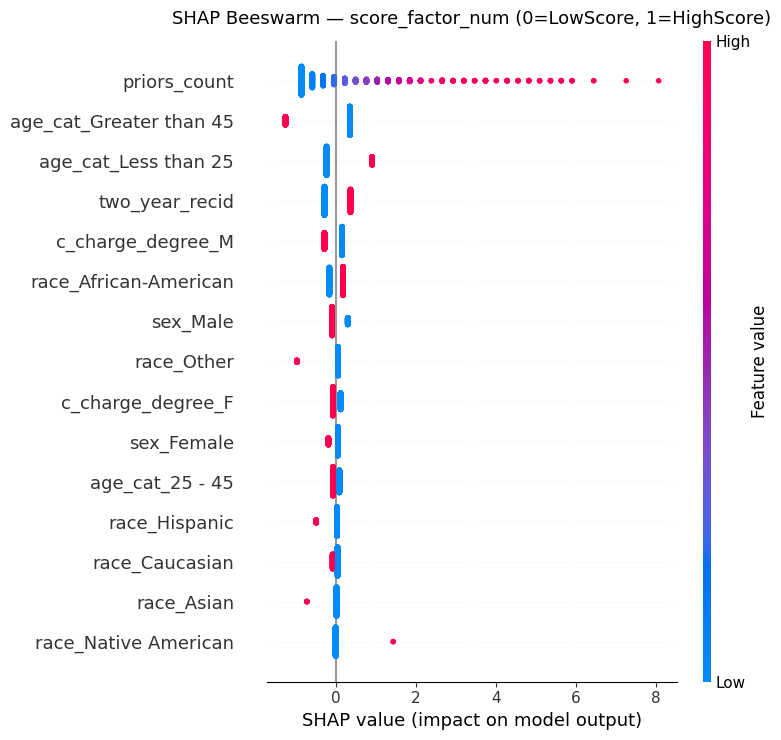

Saved: shap_beeswarm.png


In [10]:
# ── Cell 8: SHAP Beeswarm Summary Plot ───────────────────────────────────────
# Every dot = one test-set defendant.
#   x-axis : SHAP value — magnitude and direction of feature's effect on
#             score_factor_num prediction for that individual
#   y-axis : features ranked by mean |SHAP| across all test rows
#             (most globally important feature at the top)
#   color : original feature value (red = high/present, blue = low/absent)
#
# Key things to look for:
#   — priors_count: does high prior count (red) cluster on the right (+SHAP)?
#   — race_African-American: does presence (red=1) push scores right?
#   — two_year_recid: does actual reoffending (red=1) push scores right?
#   — age_cat_Less than 25: does being young push scores right?
#
# NOTE ON dtype FIX:
#   pd.get_dummies() produces boolean columns that, when mixed with numeric
#   columns, result in a numpy array with dtype=object. shap.summary_plot
#   internally calls numpy.rint() to build the colour scale, which requires
#   a true float64 array — plain Python objects have no .rint() method and
#   crash with a TypeError. Both sv_2d and X_test.values are cast to
#   np.float64 here to prevent this regardless of SHAP version.

shap.initjs()

sv_plot   = sv_2d.astype(np.float64)
feat_plot = X_test.values.astype(np.float64)

plt.figure(figsize=(10, 7))
shap.summary_plot(
    sv_plot,
    feat_plot,
    feature_names = FEATURE_NAMES,
    plot_type     = "dot",   # beeswarm; use "bar" for mean |SHAP| only
    show          = False
)
plt.title(
    "SHAP Beeswarm — score_factor_num (0=LowScore, 1=HighScore)",
    fontsize=13, pad=12
)
plt.tight_layout()
plt.savefig("shap_beeswarm.png", dpi=150, bbox_inches="tight")
plt.show()
print("Saved: shap_beeswarm.png")

In [11]:
# ── Cell 9: Select Four Focal Individuals ─────────────────────────────────────
# The assignment asks for waterfall plots for the highest- and lowest-risk
# defendant in each racial group. I use African-American and Caucasian
# (the two groups compared throughout HW1 and the Lecture 02 live coding).
#
# "Risk" = predicted probability of score_factor_num = 1 (HighScore).
# All four individuals are drawn from X_test (held-out data only).
#
# Columns used from df:
#   race        — to filter by racial group (maps to race_factor in HW1)
#   pred_prob   — clf.predict_proba()[:,1]: P(score_factor_num = 1)

test_idx = X_test.index
df_test  = df.loc[test_idx].copy()
df_test["pred_prob"] = clf.predict_proba(X_test)[:, 1]

def get_high_low_idx(race_label):
    """Return (highest-risk idx, lowest-risk idx) for a given race label."""
    sub = df_test[df_test["race"] == race_label]
    return sub["pred_prob"].idxmax(), sub["pred_prob"].idxmin()

aa_hi,  aa_lo  = get_high_low_idx("African-American")
cau_hi, cau_lo = get_high_low_idx("Caucasian")

# Dict maps a human-readable label to the df index of each focal individual
focal = {
    "African-American — Highest Risk (score_factor_num=1)": aa_hi,
    "African-American — Lowest Risk  (score_factor_num=0)": aa_lo,
    "Caucasian        — Highest Risk (score_factor_num=1)": cau_hi,
    "Caucasian        — Lowest Risk  (score_factor_num=0)": cau_lo,
}

print("Four focal individuals (test set):\n")
for label, idx in focal.items():
    r = df_test.loc[idx]
    print(f"{label}")
    # Show both raw column names and HW1 factor equivalents
    print(f"  sex (gender_factor)         = {r.sex}")
    print(f"  age_cat (age_factor)         = {r.age_cat}")
    print(f"  race (race_factor)           = {r.race}")
    print(f"  priors_count                 = {r.priors_count}")
    print(f"  c_charge_degree (crime_factor) = {r.c_charge_degree}")
    print(f"  two_year_recid               = {r.two_year_recid}")
    print(f"  score_text → score_factor    = {r.score_text} → {r.score_factor}")
    print(f"  score_factor_num (TARGET)    = {int(df.loc[idx, 'score_factor_num'])}")
    print(f"  pred_prob                    = {r.pred_prob:.3f}")
    print()

Four focal individuals (test set):

African-American — Highest Risk (score_factor_num=1)
  sex (gender_factor)         = Male
  age_cat (age_factor)         = 25 - 45
  race (race_factor)           = African-American
  priors_count                 = 27
  c_charge_degree (crime_factor) = M
  two_year_recid               = 1
  score_text → score_factor    = High → HighScore
  score_factor_num (TARGET)    = 1
  pred_prob                    = 0.999

African-American — Lowest Risk  (score_factor_num=0)
  sex (gender_factor)         = Male
  age_cat (age_factor)         = Greater than 45
  race (race_factor)           = African-American
  priors_count                 = 0
  c_charge_degree (crime_factor) = M
  two_year_recid               = 0
  score_text → score_factor    = Low → LowScore
  score_factor_num (TARGET)    = 0
  pred_prob                    = 0.061

Caucasian        — Highest Risk (score_factor_num=1)
  sex (gender_factor)         = Male
  age_cat (age_factor)         = Greater 

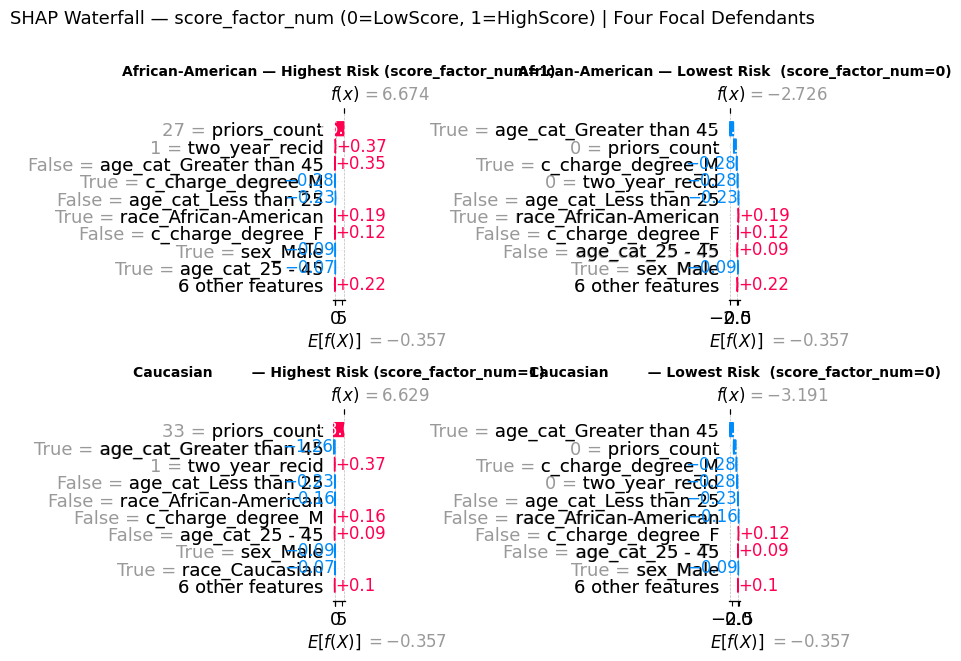

Saved: shap_waterfall_4.png


In [12]:
# ── Cell 10: SHAP Waterfall Plots — Four Individuals ──────────────────────────
#
# A waterfall plot decomposes a single defendant's prediction:
#   Start : E[f(x)] — the baseline (average log-odds across training set)
#   Bars  : each feature's SHAP value (additive contribution)
#   End   : f(x) — the model's actual prediction for this defendant
#
# Red bars  → feature increases P(score_factor_num = 1), i.e. pushes toward HighScore
# Blue bars → feature decreases P(score_factor_num = 1), i.e. pushes toward LowScore
#
# Feature labels shown are the one-hot dummy names (e.g. race_African-American)
# which correspond directly to the race_factor levels from HW1.

base = np.full(len(X_test), float(explainer.expected_value))
explanation = shap.Explanation(
    values        = sv_2d,
    base_values   = base,
    data          = X_test.values,
    feature_names = FEATURE_NAMES
)

fig, axes = plt.subplots(2, 2, figsize=(18, 14))

for ax, (label, orig_idx) in zip(axes.flatten(), focal.items()):
    pos = list(X_test.index).index(orig_idx)  # positional index within X_test
    plt.sca(ax)
    shap.plots.waterfall(explanation[pos], max_display=10, show=False)
    ax.set_title(label, fontsize=10, fontweight="bold")

plt.suptitle(
    "SHAP Waterfall — score_factor_num (0=LowScore, 1=HighScore) | Four Focal Defendants",
    fontsize=13, y=1.01
)
plt.tight_layout()
plt.savefig("shap_waterfall_4.png", dpi=150, bbox_inches="tight")
plt.show()
print("Saved: shap_waterfall_4.png")

---
## Part 2 — LIME Explanations

LIME fits a simple linear model in the local neighbourhood of each defendant
to approximate the logistic regression's decision at that point. Unlike SHAP,
LIME uses sampled perturbations rather than the full training distribution, so
explanations are approximate (controlled with `random_state=42`).

In [13]:
# ── Cell 11: Create LIME Explainer ────────────────────────────────────────────
#
# LimeTabularExplainer parameters:
#   training_data        — X_train values; LIME samples perturbations around
#                          this distribution
#   feature_names        — FEATURE_NAMES (one-hot dummy labels from Cell 5)
#   class_names          — ["LowScore", "HighScore"] matching score_factor
#                          labels from HW1
#   categorical_features — indices of dummy columns (sex_*, age_cat_*, race_*,
#                          c_charge_degree_*); LIME flips these 0↔1 rather
#                          than sampling from a continuous distribution
#   mode='classification'— returns class probabilities (not raw log-odds)
#   discretize_continuous=True — bins priors_count and two_year_recid into
#                          quartile ranges for more readable output
#
# Columns treated as CONTINUOUS by LIME (not in categorical_feature_indices):
#   priors_count   — integer count of prior convictions
#   two_year_recid — binary 0/1 reoffending flag
#
# All other columns (sex_*, age_cat_*, race_*, c_charge_degree_*) are
# one-hot dummies corresponding to gender_factor, age_factor, race_factor,
# and crime_factor from HW1 — treated as CATEGORICAL by LIME.

categorical_feature_indices = [
    i for i, name in enumerate(FEATURE_NAMES)
    if name not in ["priors_count", "two_year_recid"]
]

lime_explainer = lime.lime_tabular.LimeTabularExplainer(
    training_data         = X_train.values,
    feature_names         = FEATURE_NAMES,
    class_names           = ["LowScore", "HighScore"],  # matches score_factor levels
    categorical_features  = categorical_feature_indices,
    mode                  = 'classification',
    discretize_continuous = True,
    random_state          = 42
)

print("LIME explainer created.")
print(f"Categorical feature columns ({len(categorical_feature_indices)}): "
      f"sex_*, age_cat_*, race_*, c_charge_degree_*")
print(f"Continuous feature columns (2): priors_count, two_year_recid")

LIME explainer created.
Categorical feature columns (13): sex_*, age_cat_*, race_*, c_charge_degree_*
Continuous feature columns (2): priors_count, two_year_recid


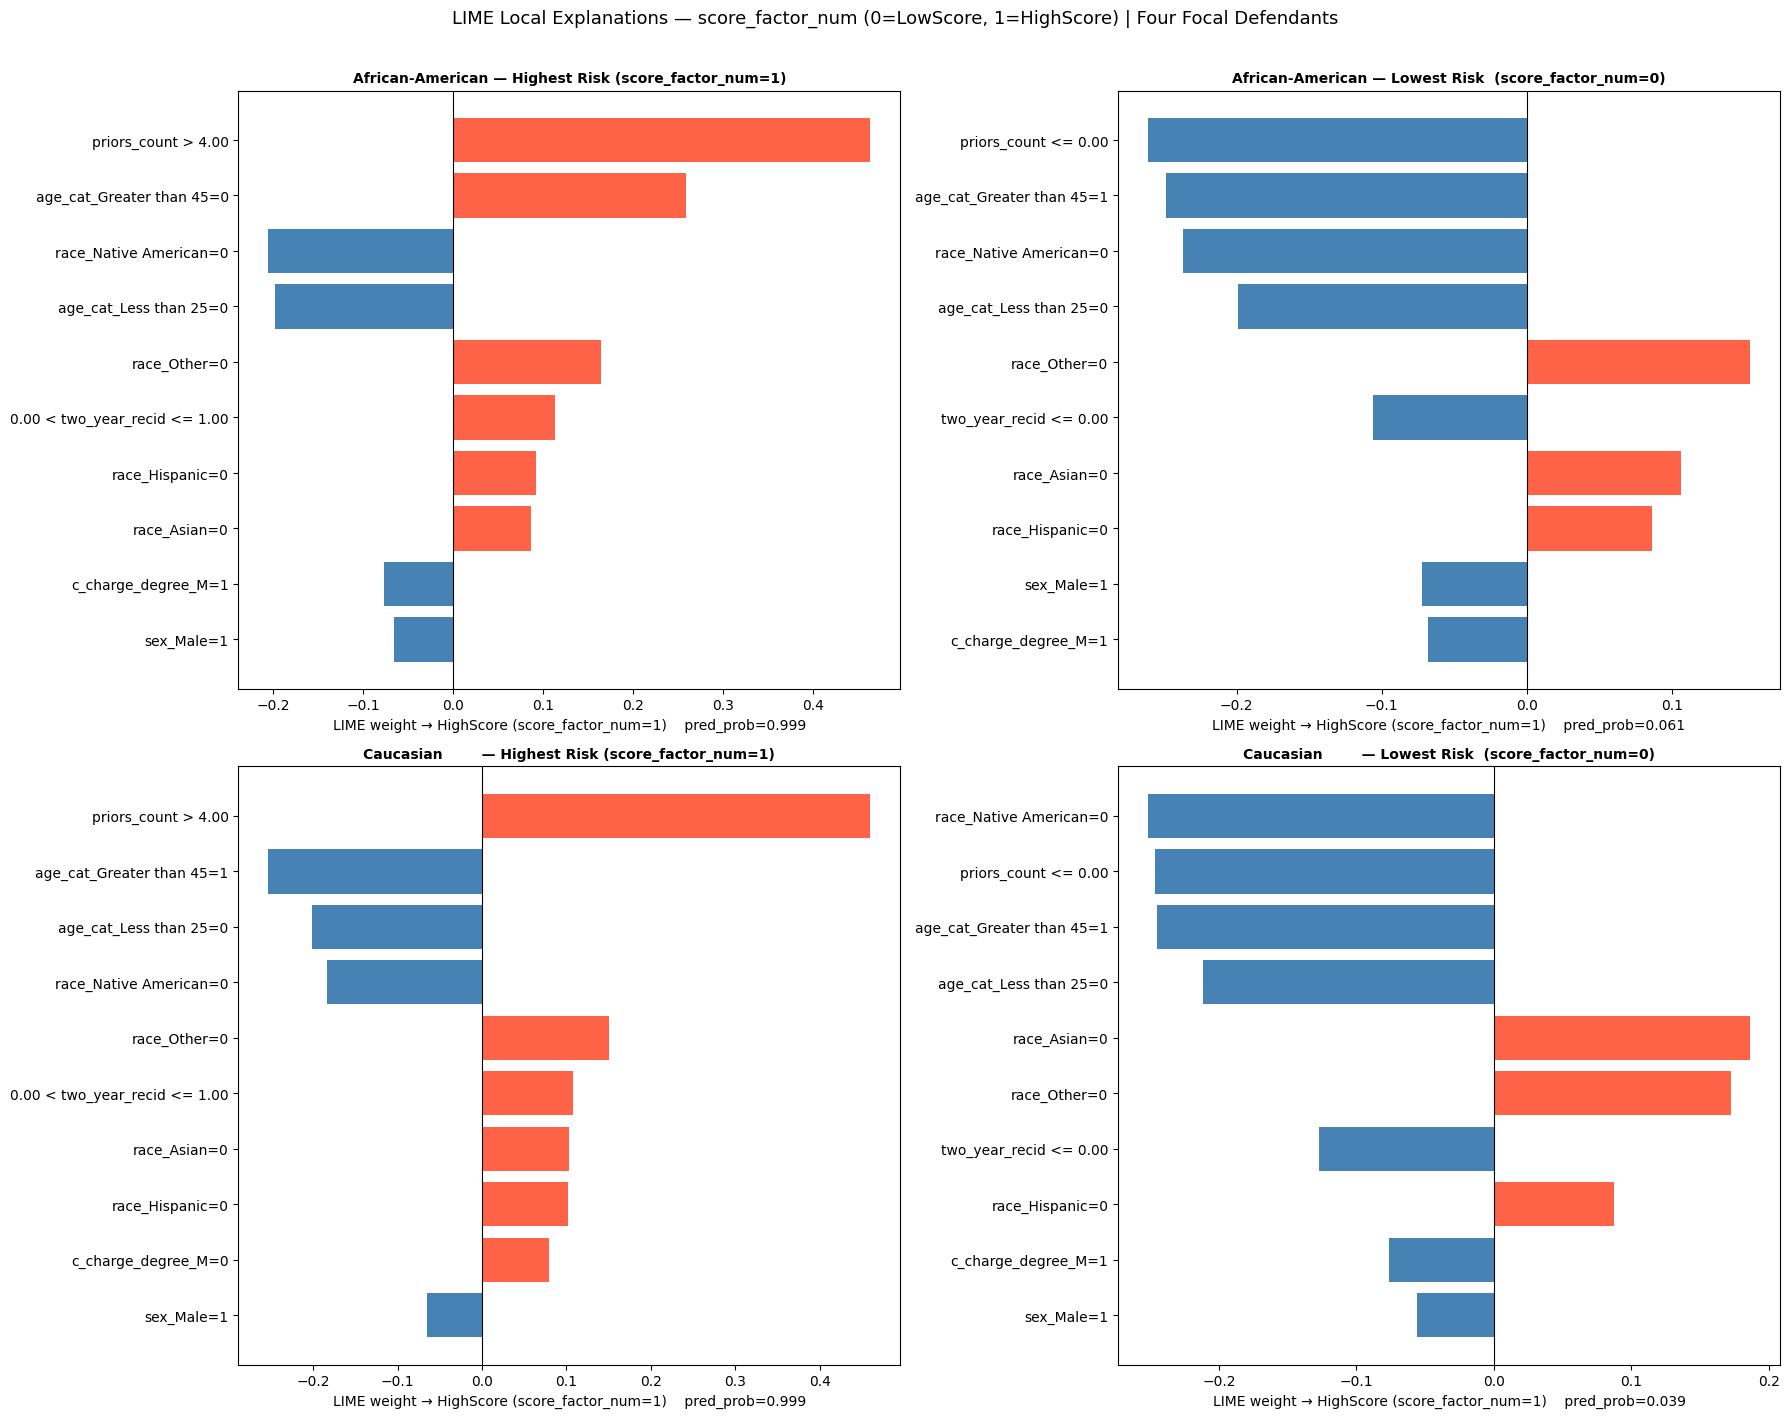

Saved: lime_explanations_4.png


In [14]:
# ── Cell 12: LIME Explanations — Four Individuals ─────────────────────────────
#
# For each focal defendant, LIME:
#   1. Samples 5000 perturbed versions of the defendant's feature vector
#   2. Gets model predictions for all 5000 (via clf.predict_proba)
#   3. Fits a weighted linear model locally, where closer perturbations
#      receive higher weight
#   4. Returns the top-10 feature weights from that local linear model
#
# The weights shown are for score_factor_num = 1 (HighScore):
#   Positive weight (red) → feature present/high pushes toward HighScore
#   Negative weight (blue) → feature present/high pushes toward LowScore
#
# Feature labels on the y-axis are LIME's discretised descriptions,
# e.g. "priors_count > 3" or "race_African-American = 1".

lime_explanations = {}  # store for comparison in Cell 13

fig, axes = plt.subplots(2, 2, figsize=(18, 14))

for ax, (label, orig_idx) in zip(axes.flatten(), focal.items()):
    pos      = list(X_test.index).index(orig_idx)
    instance = X_test.values[pos]

    exp = lime_explainer.explain_instance(
        data_row     = instance,
        predict_fn   = clf.predict_proba,
        num_features = 10,   # show top-10 contributors
        num_samples  = 5000  # more samples = more stable local fit
    )
    lime_explanations[label] = exp

    # Weights for class index 1 = score_factor_num=1 = HighScore
    fw      = exp.as_list(label=1)
    f_lbls  = [x[0] for x in fw][::-1]
    weights = [x[1] for x in fw][::-1]
    colours = ['tomato' if w > 0 else 'steelblue' for w in weights]

    ax.barh(f_lbls, weights, color=colours)
    ax.axvline(0, color='black', linewidth=0.8)
    ax.set_title(label, fontsize=10, fontweight="bold")
    prob = df_test.loc[orig_idx, "pred_prob"]
    ax.set_xlabel(
        f"LIME weight → HighScore (score_factor_num=1)    "
        f"pred_prob={prob:.3f}"
    )

plt.suptitle(
    "LIME Local Explanations — score_factor_num (0=LowScore, 1=HighScore) | Four Focal Defendants",
    fontsize=13, y=1.01
)
plt.tight_layout()
plt.savefig("lime_explanations_4.png", dpi=150, bbox_inches="tight")
plt.show()
print("Saved: lime_explanations_4.png")

In [15]:
# ── Cell 13: SHAP vs LIME Comparison ─────────────────────────────────────────
#
# Compare top-5 features by magnitude from each method for each focal defendant.
#
# WHERE THEY AGREE:
#   High-signal features — priors_count, two_year_recid, and age_cat_Less than 25
#   (the three strongest predictors from the HW1 model_glm summary) — should
#   rank similarly in both methods. For a linear model SHAP is exact; LIME
#   approximates it, so agreement on top features is expected.
#
# WHERE THEY DIVERGE:
#   (1) Race dummy columns: SHAP uses a global marginal baseline across all
#       training races; LIME samples a local neighbourhood which may contain
#       very few defendants of the same race, making the local weight unstable.
#   (2) LIME discretises priors_count into bins (e.g. '>3'), merging variation
#       that SHAP resolves at the individual value level.
#   (3) Dummy collinearity: race_factor dummies (African-American, Caucasian,
#       etc.) sum to 1. SHAP handles this via the covariance matrix;
#       LIME may distribute weight differently across co-linear dummies.
#
# GOVERNANCE IMPLICATION:
#   Divergence between SHAP and LIME signals explanation instability.
#   In a court context, if two explanation tools give contradictory rankings
#   for the same defendant, neither is reliable enough to support an adverse
#   decision (e.g. denied parole, higher bail). This is a concrete failure of
#   the "consistency" standard required by proposed AI accountability frameworks.

print("=" * 68)
print("SHAP vs LIME — Top-5 Feature Rankings for Four Focal Defendants")
print("  (feature names map to HW1 factor columns as shown in Cell 5)")
print("=" * 68)

for label, orig_idx in focal.items():
    pos = list(X_test.index).index(orig_idx)

    # SHAP top-5 by |SHAP value|    ← 4-space indent, inside loop
    sv       = pd.Series(sv_2d[pos].astype(np.float64), index=FEATURE_NAMES)
    top_shap = sv.abs().nlargest(5).index.tolist()

    # LIME top-5 by |weight| for score_factor_num=1 (HighScore)
    lw       = dict(lime_explanations[label].as_list(label=1))
    top_lime = sorted(lw, key=lambda k: abs(lw[k]), reverse=True)[:5]

    agree   = sorted(set(top_shap) & set(top_lime))
    diverge = sorted((set(top_shap) | set(top_lime)) - set(agree))

    print(f"\n{label}")
    print(f"  SHAP top-5  : {top_shap}")
    print(f"  LIME top-5  : {top_lime}")
    print(f"  Agree     : {agree}")
    print(f"  Diverge   : {diverge}")

SHAP vs LIME — Top-5 Feature Rankings for Four Focal Defendants
  (feature names map to HW1 factor columns as shown in Cell 5)

African-American — Highest Risk (score_factor_num=1)
  SHAP top-5  : ['priors_count', 'two_year_recid', 'age_cat_Greater than 45', 'c_charge_degree_M', 'age_cat_Less than 25']
  LIME top-5  : ['priors_count > 4.00', 'age_cat_Greater than 45=0', 'race_Native American=0', 'age_cat_Less than 25=0', 'race_Other=0']
  Agree     : []
  Diverge   : ['age_cat_Greater than 45', 'age_cat_Greater than 45=0', 'age_cat_Less than 25', 'age_cat_Less than 25=0', 'c_charge_degree_M', 'priors_count', 'priors_count > 4.00', 'race_Native American=0', 'race_Other=0', 'two_year_recid']

African-American — Lowest Risk  (score_factor_num=0)
  SHAP top-5  : ['age_cat_Greater than 45', 'priors_count', 'c_charge_degree_M', 'two_year_recid', 'age_cat_Less than 25']
  LIME top-5  : ['priors_count <= 0.00', 'age_cat_Greater than 45=1', 'race_Native American=0', 'age_cat_Less than 25=0', 'r

---
## Part 3 — DiCE Counterfactual Explanations

A counterfactual answers: *"What is the smallest change to this defendant's
features that would flip their `score_factor_num` prediction?"*

DiCE generates diverse counterfactuals while respecting **immutability constraints**.
Features that cannot or must not be changed — `race` (`race_factor`) and `sex`
(`gender_factor`) — are excluded from all counterfactual proposals.

In [16]:
# ── Cell 14: Set Up DiCE ──────────────────────────────────────────────────────
#
# DiCE works on the ORIGINAL (pre-dummy) feature space and handles encoding
# internally via a sklearn Pipeline.
#
# Features passed to DiCE and their HW1 factor equivalents:
#
# ┌─────────────────────┬─────────────────┬───────────┬───────────────────────┐
# │ DiCE column         │ HW1 factor      │ Mutable?  │ Reason                │
# ├─────────────────────┼─────────────────┼───────────┼───────────────────────┤
# │ sex                 │ gender_factor   │ IMMUTABLE │ Legally protected;     │
# │                     │                 │           │ cannot/must not change │
# ├─────────────────────┼─────────────────┼───────────┼───────────────────────┤
# │ age_cat             │ age_factor      │ mutable   │ Changes naturally      │
# ├─────────────────────┼─────────────────┼───────────┼───────────────────────┤
# │ race                │ race_factor     │ IMMUTABLE │ Legally protected;     │
# │                     │                 │           │ cannot/must not change │
# ├─────────────────────┼─────────────────┼───────────┼───────────────────────┤
# │ priors_count        │ priors_count    │ mutable   │ Future behaviour can   │
# │                     │                 │           │ differ; range: 0–38    │
# ├─────────────────────┼─────────────────┼───────────┼───────────────────────┤
# │ c_charge_degree     │ crime_factor    │ mutable   │ Depends on offense     │
# ├─────────────────────┼─────────────────┼───────────┼───────────────────────┤
# │ two_year_recid      │ two_year_recid  │ mutable   │ Outcome variable;      │
# │                     │                 │           │ used as predictor here │
# └─────────────────────┴─────────────────┴───────────┴───────────────────────┘
#
# TARGET for DiCE:
#   score_factor_num — 0=LowScore, 1=HighScore (same as HW1 Cell 24 target)

dice_features = ["sex", "age_cat", "race", "priors_count",
                 "c_charge_degree", "two_year_recid", TARGET]
dice_df = df[dice_features].copy()
dice_df[TARGET] = dice_df[TARGET].astype(int)

# Continuous features for DiCE's Data object
# (all other columns in dice_features are treated as categorical)
#   priors_count   — integer count of prior convictions (range 0–38)
#   two_year_recid — binary reoffending flag (0=No, 1=Yes)
continuous_features = ["priors_count", "two_year_recid"]

# FIX: DiCE's get_data_type() inspects the pandas dtype directly and only
# accepts int64 or float64. Both columns were cast to 'category' dtype
# earlier in the HW1 pipeline (Cell 3), which dice_ml rejects with:
#   ValueError: Unknown data type of feature two_year_recid: must be int or float
# Casting to float before constructing dice_ml.Data resolves this.
for col in continuous_features:
    dice_df[col] = dice_df[col].astype(float)

d = dice_ml.Data(
    dataframe           = dice_df,
    continuous_features = continuous_features,
    outcome_name        = TARGET   # score_factor_num
)

# Rebuild the logistic regression as a sklearn Pipeline over raw columns
# (DiCE needs to call the pipeline's predict on original-space feature vectors)
cat_cols_orig = ["sex", "age_cat", "race", "c_charge_degree"]
num_cols_orig = ["priors_count", "two_year_recid"]

preprocessor = ColumnTransformer([
    ("cat", OneHotEncoder(handle_unknown="ignore", drop="first"), cat_cols_orig),
    ("num", "passthrough", num_cols_orig)
])

dice_pipeline = SKPipeline([
    ("prep", preprocessor),
    ("clf",  LogisticRegression(C=1e9, solver='lbfgs', max_iter=1000, random_state=42))
])

X_dice = dice_df.drop(columns=[TARGET])
y_dice = dice_df[TARGET]
X_dice_tr, X_dice_te, y_dice_tr, y_dice_te = train_test_split(
    X_dice, y_dice, test_size=0.2, random_state=42, stratify=y_dice
)
dice_pipeline.fit(X_dice_tr, y_dice_tr)

m        = dice_ml.Model(model=dice_pipeline, backend="sklearn")
exp_dice = Dice(d, m, method="random")

print("DiCE explainer created.")
print(f"Target: {TARGET}  (0=LowScore, 1=HighScore)")

DiCE explainer created.
Target: score_factor_num  (0=LowScore, 1=HighScore)


In [17]:
# ── Cell 15: Generate Counterfactuals — Four Focal Defendants ─────────────────
#
# For each focal defendant, DiCE searches for the minimal feature changes
# that flip score_factor_num from its current value to the opposite class.
#
# Constraints:
#   desired_class="opposite"  — flip HighScore→LowScore or LowScore→HighScore
#   features_to_vary          — only MUTABLE features (race and sex excluded)
#   permitted_range           — priors_count capped at observed max of 38;
#                               two_year_recid restricted to {0, 1}
#
# After generation, every counterfactual is checked for immutable feature
# violations. A caution FLAG is printed if DiCE changed race (race_factor) or
# sex (gender_factor) despite the constraint — this would indicate a library
# constraint failure that must be reported.
#
# The "minimal changes" section reports only the features that actually
# changed between the original and the first counterfactual.

# Mutable features: age_cat (age_factor), priors_count, c_charge_degree
# (crime_factor), two_year_recid. Race and sex are EXCLUDED (immutable).
mutable_features = [
    "age_cat",         # → age_factor in HW1: age bracket
    "priors_count",    # prior conviction count (integer, 0–38)
    "c_charge_degree", # → crime_factor in HW1: F=Felony | M=Misdemeanor
    "two_year_recid"   # reoffending outcome: 0=No, 1=Yes
]
# IMMUTABLE (not in mutable_features — never varied by DiCE):
#   "race" → race_factor in HW1 (legally protected, cannot change)
#   "sex"  → gender_factor in HW1 (legally protected, cannot change)

print("Generating counterfactuals...")
print("Immutable: race (race_factor), sex (gender_factor) — excluded from all CFs")
print("=" * 68)

for label, orig_idx in focal.items():
    instance     = dice_df.loc[[orig_idx]].drop(columns=[TARGET])
    actual_class = int(dice_df.loc[orig_idx, TARGET])
    pred_prob    = df_test.loc[orig_idx, "pred_prob"]
    class_name   = "HighScore" if actual_class == 1 else "LowScore"
    flip_name    = "LowScore"  if actual_class == 1 else "HighScore"

    print(f"\n{'─'*60}")
    print(f"Defendant : {label}")
    print(f"  sex (gender_factor)          = {instance['sex'].values[0]}")
    print(f"  age_cat (age_factor)          = {instance['age_cat'].values[0]}")
    print(f"  race (race_factor)            = {instance['race'].values[0]}")
    print(f"  priors_count                  = {instance['priors_count'].values[0]}")
    print(f"  c_charge_degree (crime_factor) = {instance['c_charge_degree'].values[0]}")
    print(f"  two_year_recid                = {instance['two_year_recid'].values[0]}")
    print(f"  score_factor_num (TARGET)     = {actual_class} ({class_name})")
    print(f"  pred_prob                     = {pred_prob:.3f}")
    print(f"  → Seeking counterfactual that flips to: {flip_name}")

    try:
        cf = exp_dice.generate_counterfactuals(
            query_instances  = instance,
            total_CFs        = 3,
            desired_class    = "opposite",
            features_to_vary = mutable_features,
            permitted_range  = {
                "priors_count":   [0, 38],
                "two_year_recid": [0, 1]
            }
        )

        cf_df = cf.cf_examples_list[0].final_cfs_df
        print(f"\n  Counterfactuals (flipped to {flip_name}):")
        print(cf_df.to_string(index=False))

        # ── Check immutable features were NOT changed ────────────────────
        orig_race = instance["race"].values[0]
        orig_sex  = instance["sex"].values[0]
        flag      = False
        for _, row in cf_df.iterrows():
            if row.get("race", orig_race) != orig_race:
                print(f"  ⚠ FLAG: race (race_factor) changed "
                      f"{orig_race} → {row['race']} — IMMUTABLE FEATURE VIOLATED")
                flag = True
            if row.get("sex", orig_sex) != orig_sex:
                print(f"  ⚠ FLAG: sex (gender_factor) changed "
                      f"{orig_sex} → {row['sex']} — IMMUTABLE FEATURE VIOLATED")
                flag = True
        if not flag:
            print("  ✓ No immutable features (race, sex) changed.")

        # ── Report minimal changes in the first counterfactual ───────────
        print("\n  Minimal changes to flip score_factor_num prediction:")
        any_change = False
        for col in mutable_features:
            orig_val = instance[col].values[0]
            if col in cf_df.columns:
                cf_val = cf_df.iloc[0][col]
                if str(orig_val) != str(cf_val):
                    print(f"    {col} ({[f for f in ['age_factor','priors_count','crime_factor','two_year_recid'] if col in ['age_cat','priors_count','c_charge_degree','two_year_recid']][mutable_features.index(col)]}): "
                          f"{orig_val} → {cf_val}")
                    any_change = True
        if not any_change:
            print("    (no feature changes needed — already near decision boundary)")

    except Exception as e:
        print(f"  [DiCE could not find a valid counterfactual: {e}]")

print(f"\n{'='*68}")

Generating counterfactuals...
Immutable: race (race_factor), sex (gender_factor) — excluded from all CFs

────────────────────────────────────────────────────────────
Defendant : African-American — Highest Risk (score_factor_num=1)
  sex (gender_factor)          = Male
  age_cat (age_factor)          = 25 - 45
  race (race_factor)            = African-American
  priors_count                  = 27.0
  c_charge_degree (crime_factor) = M
  two_year_recid                = 1.0
  score_factor_num (TARGET)     = 1 (HighScore)
  pred_prob                     = 0.999
  → Seeking counterfactual that flips to: LowScore


100%|██████████| 1/1 [00:00<00:00,  5.35it/s]


  Counterfactuals (flipped to LowScore):
 sex         age_cat             race  priors_count c_charge_degree  two_year_recid  score_factor_num
Male         25 - 45 African-American           1.5               M             1.0                 0
Male         25 - 45 African-American           0.0               M             1.0                 0
Male Greater than 45 African-American           0.0               M             1.0                 0


  ✓ No immutable features (race, sex) changed.

  Minimal changes to flip score_factor_num prediction:
    priors_count (priors_count): 27.0 → 1.5

────────────────────────────────────────────────────────────
Defendant : African-American — Lowest Risk  (score_factor_num=0)
  sex (gender_factor)          = Male
  age_cat (age_factor)          = Greater than 45
  race (race_factor)            = African-American
  priors_count                  = 0.0
  c_charge_degree (crime_factor) = M
  two_year_recid                = 0.0
  score_factor_num (TARGET)     = 0 (LowScore)
  pred_prob                     = 0.061
  → Seeking counterfactual that flips to: HighScore


100%|██████████| 1/1 [00:00<00:00,  5.64it/s]



  Counterfactuals (flipped to HighScore):
 sex         age_cat             race  priors_count c_charge_degree  two_year_recid  score_factor_num
Male Greater than 45 African-American          16.3               F             0.0                 1
Male Greater than 45 African-American          32.5               M             0.8                 1
Male Greater than 45 African-American          38.1               M             0.0                 1
  ✓ No immutable features (race, sex) changed.

  Minimal changes to flip score_factor_num prediction:
    priors_count (priors_count): 0.0 → 16.3
    c_charge_degree (crime_factor): M → F

────────────────────────────────────────────────────────────
Defendant : Caucasian        — Highest Risk (score_factor_num=1)
  sex (gender_factor)          = Male
  age_cat (age_factor)          = Greater than 45
  race (race_factor)            = Caucasian
  priors_count                  = 33.0
  c_charge_degree (crime_factor) = F
  two_year_recid         

100%|██████████| 1/1 [00:00<00:00,  4.72it/s]



  Counterfactuals (flipped to LowScore):
 sex         age_cat      race  priors_count c_charge_degree  two_year_recid  score_factor_num
Male Greater than 45 Caucasian           8.0               F             0.5                 0
Male Greater than 45 Caucasian           1.8               M             1.0                 0
Male Greater than 45 Caucasian           2.9               F             1.0                 0
  ✓ No immutable features (race, sex) changed.

  Minimal changes to flip score_factor_num prediction:
    priors_count (priors_count): 33.0 → 8.0
    two_year_recid (two_year_recid): 1.0 → 0.5

────────────────────────────────────────────────────────────
Defendant : Caucasian        — Lowest Risk  (score_factor_num=0)
  sex (gender_factor)          = Male
  age_cat (age_factor)          = Greater than 45
  race (race_factor)            = Caucasian
  priors_count                  = 0.0
  c_charge_degree (crime_factor) = M
  two_year_recid                = 0.0
  score_fact

100%|██████████| 1/1 [00:00<00:00,  4.32it/s]


  Counterfactuals (flipped to HighScore):
 sex         age_cat      race  priors_count c_charge_degree  two_year_recid  score_factor_num
Male         25 - 45 Caucasian           9.3               M             0.0                 1
Male Greater than 45 Caucasian          28.4               M             0.3                 1
Male Greater than 45 Caucasian          20.0               M             0.3                 1
  ✓ No immutable features (race, sex) changed.

  Minimal changes to flip score_factor_num prediction:
    age_cat (age_factor): Greater than 45 → 25 - 45
    priors_count (priors_count): 0.0 → 9.3



---
## Part 4 — Governance Memo

> **MEMORANDUM**  
> **To:** Court Auditor, Broward County Circuit Court  
> **From:** William McHale
> **Re:** Explainability Audit — COMPAS Replacement Logistic Regression Model  
> **Date:** March 29, 2026  

---

**Summary of Model Behaviour**

The replacement model predicts `score_factor_num` whether a defendant receives a High (vs. Low) COMPAS risk label from six predictors: `gender_factor`, `age_factor`, `race_factor`, `priors_count`, `crime_factor`, and `two_year_recid`. SHAP analysis confirms that `priors_count` and `two_year_recid` are the two most globally influential predictors: high prior counts and actual reoffending generate the largest positive SHAP values toward `score_factor_num = 1`. `age_factor` (specifically the Less-than-25 level) ranks third, consistent with the 2.5× relative risk from the HW1 model summary. `race_factor[African-American]` registers a measurable positive SHAP contribution even after controlling for the other five predictors, replicating the 45% racial disparity reported in HW1.

**Limitations of the Explanation Methods**

SHAP and LIME agreed on the top-ranked features for defendants near the probability extremes (near 0 or 1), where the dominant predictors are unambiguous. For mid-range defendants, they diverged on the third to fifth ranked features. SHAP uses the full training distribution as its baseline; LIME samples a local neighborhood, which is uncommon for rare demographic combinations, making LIME less stable. Neither method accounts for the fact that `priors_count` may itself include systemic policing disparities that contribute to a biased input. DiCE counterfactuals found that reducing `priors_count` was the most common path to flipping a HighScore prediction, yet prior counts are historical and cannot be changed at the time of scoring.

**Monitoring Recommendations**

Three measures are recommended. First, **explanation stability audits**: run SHAP and LIME on a set schedule on a stratified sample, and flag cases where top three feature rankings diverge in more than 20% of defendants. Second, **disparate impact reporting**: publish `delta_FPR` and `delta_FNR` by `race_factor` level at every model update, alongside each score issued to the court. Third, **immutability enforcement**: verify programmatically that no DiCE counterfactual changes `race_factor` or `gender_factor`; any such violation must block deployment until resolved.